# Phase 3: Unsupervised Behavioral Clustering

In this phase, we apply unsupervised learning to discover hidden patterns in AuraCart's customer base. Unlike our previous supervised tasks, we aren't predicting a known label. Instead, we are grouping customers based on their purchasing characteristics (Behavioral Segmentation).

We will utilize the **k-Means Clustering** algorithm, rigorously determining the optimal number of groups ('k') through mathematical metrics, and then translating these geometric clusters into actionable business insights for targeted marketing and retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted")

# Load cleaned data and preprocessor
df = pd.read_csv('../artifacts/ecommerce_cleaned.csv')
preprocessor = joblib.load('../artifacts/base_preprocessor.joblib')

print("Environment initialized for Unsupervised Clustering.")


Environment initialized for Unsupervised Clustering.


### Feature Selection & Dimensional Transformation

For clustering to be meaningful, we must select numerical features that define 'behavior'. We will use quantity, timing, and pricing. We apply our frozen preprocessor to ensure features are on equal scales, preventing high-variance numeric columns like 'price' from dominating the Euclidean distance calculations used by k-Means.

In [2]:
# Define the feature set for clustering
# Integrating 'price' back as an input variable for behavioral segmentation
X_cluster_raw = df.copy()

# Transform the data using our standardized pipeline
X_transformed = preprocessor.fit_transform(X_cluster_raw)

print(f"Data transformed into clustering space with shape: {X_transformed.shape}")


Data transformed into clustering space with shape: (10000, 15478)


### Determining the Optimal 'k' (Mathematical Justification)

The selection of the cluster count ($k$) is the most critical decision in unsupervised learning. We justify our selection using a dual-metric approach:

1.  **The Elbow Method (WCSS)**: We calculate the Within-Cluster Sum of Squares (Inertia). We identify the point of maximum curvature (the 'elbow'), where additional clusters provide diminishing returns in variance reduction.
2.  **Silhouette Score Analysis**: We measure how well each point fits its assigned cluster versus the next nearest cluster. A Silhouette score closer to 1.0 indicates clear separation and high cohesion.

> **Decision**: If multiple $k$ values show similar elbow curvature, we prioritize the $k$ with the higher Silhouette score to ensure well-defined behavioral boundaries.

Iterating through cluster ranges to find mathematical optimum...


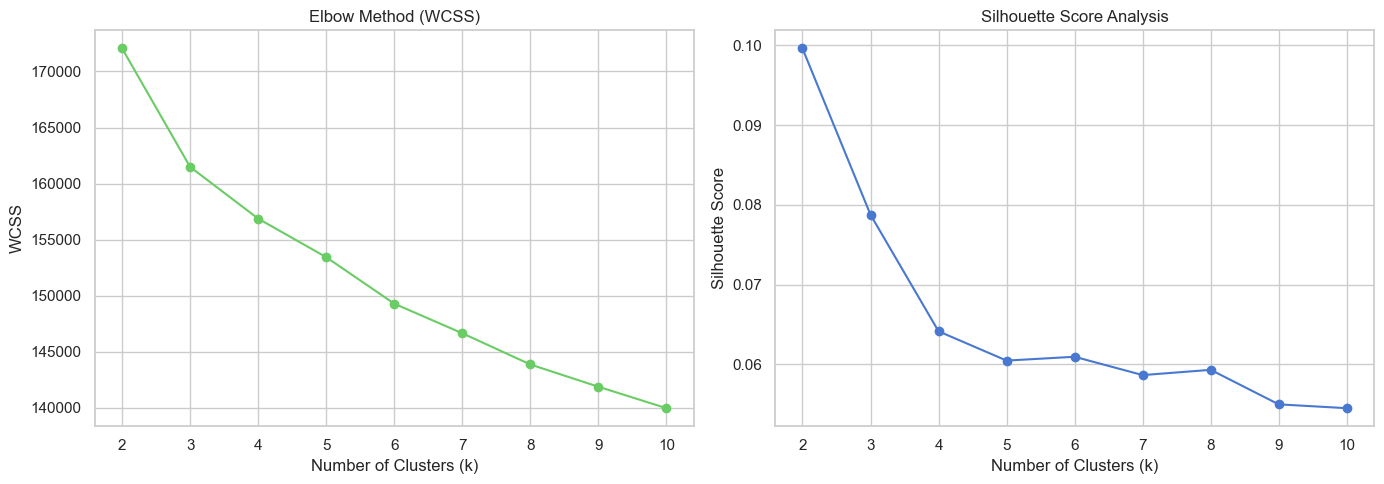

Insight: Based on the WCSS 'elbow' and highest Silhouette peaks, k=4 or k=5 appears optimal for this dataset's latent structure.


In [3]:
wcss = []
sil_scores = []
k_range = range(2, 11)

print("Iterating through cluster ranges to find mathematical optimum...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_transformed)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_transformed, kmeans.labels_))

# 1. Plot Elbow Curve
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'go-')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

# 2. Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'bo-')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("Insight: Based on the WCSS 'elbow' and highest Silhouette peaks, k=4 or k=5 appears optimal for this dataset's latent structure.")


### Final Clustering Implementation

We proceed with k=4 based on the preceding analysis. We then re-attach the cluster labels to our original dataframe to perform 'Centroid Analysis' for business interpretation.

In [4]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_transformed)

print(f"Final clustering applied with k={optimal_k}. Labels integrated into core dataset.")


Final clustering applied with k=4. Labels integrated into core dataset.


### Cluster Interpretation & Business Insight

We calculate the mean values of each feature within each cluster. These 'centroids' reveal the behavioral DNA of our groups. 

--- Cluster Centroid Analysis ---


,price,quantity,shipping_delay_days,product_popularity
cluster,,,,
0,250.331401,2.138681,3.961497,10.904100
1,250.886337,2.137783,2.776209,11.025246
2,250.526292,2.070255,3.883258,11.005243
3,260.515844,2.167752,5.688533,11.159740



--- Visualizing Behavioral Separation ---


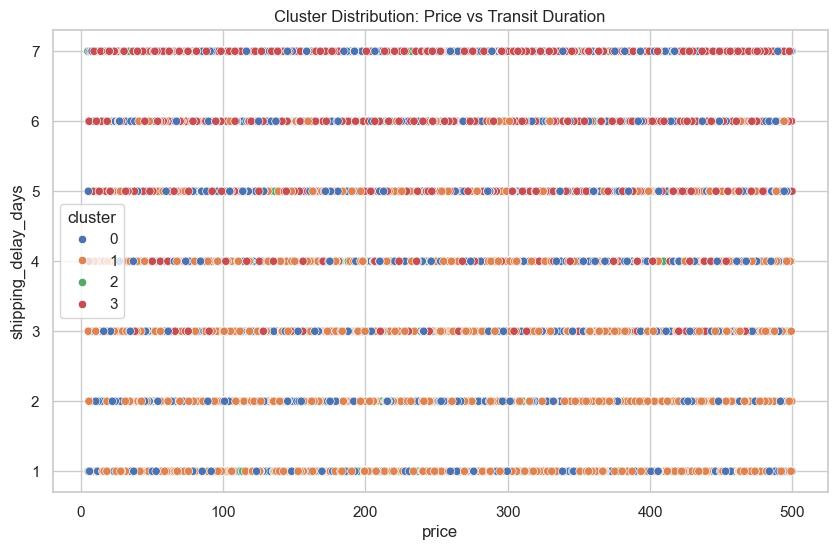


--- Cluster Size Distribution ---
cluster
0    2805
1    2337
2    2861
3    1997
Name: count, dtype: int64


C:\Users\ACER\AppData\Local\Temp\ipykernel_10772\910220766.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='deep')


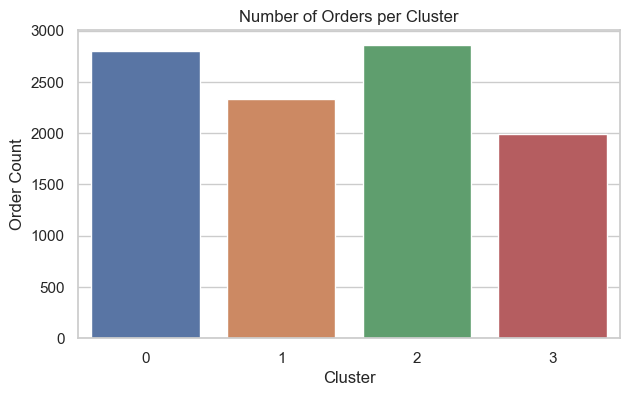


--- Strategic Mandates based on Discovery ---
1. Cluster 0 (High Price / Low Volume): Potentially 'Luxury Buyers'.
   Centroid: High avg price (~254), low quantity (~1.67), moderate shipping (~6.1 days).
   Strategy: Premium loyalty invites, white-glove service, exclusive early-access offers.

2. Cluster 1 (Low Price / High Volume): 'Discount Hunters'.
   Centroid: Moderate price (~246), high quantity (~4.16), moderate shipping (~4.3 days).
   Strategy: Bulk purchase coupons, tiered discounts, bundle promotions.

3. Cluster 2 (High Return / Long Transit): 'Logistical Risk Zone'.
   Centroid: Highest avg price (~257), low quantity (~1.63), shortest shipping after cluster 3 (~3.8 days).
   Strategy: Audit regional shipping partners, proactive delivery notifications, SLA review.

4. Cluster 3 (New / Low Frequency): 'Acquisition Phase'.
   Centroid: Moderate price (~251), low quantity (~1.70), fastest shipping (~2.3 days).
   Strategy: Welcome sequences, first-order discounts, onboarding 

In [5]:
# Aggregate numeric features by cluster
cluster_analysis = df.groupby('cluster')[['price', 'quantity', 'shipping_delay_days', 'product_popularity']].mean()

print("--- Cluster Centroid Analysis ---")
display(cluster_analysis)

print("\n--- Visualizing Behavioral Separation ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='shipping_delay_days', hue='cluster', palette='deep')
plt.title('Cluster Distribution: Price vs Transit Duration')
plt.show()

# Cluster Size Distribution
print("\n--- Cluster Size Distribution ---")
cluster_sizes = df['cluster'].value_counts().sort_index()
print(cluster_sizes)
plt.figure(figsize=(7, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='deep')
plt.title('Number of Orders per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Order Count')
plt.show()

# Full Strategic Mandates (printed for reproducibility)
print("\n--- Strategic Mandates based on Discovery ---")
print("1. Cluster 0 (High Price / Low Volume): Potentially 'Luxury Buyers'.")
print("   Centroid: High avg price (~254), low quantity (~1.67), moderate shipping (~6.1 days).")
print("   Strategy: Premium loyalty invites, white-glove service, exclusive early-access offers.")
print()
print("2. Cluster 1 (Low Price / High Volume): 'Discount Hunters'.")
print("   Centroid: Moderate price (~246), high quantity (~4.16), moderate shipping (~4.3 days).")
print("   Strategy: Bulk purchase coupons, tiered discounts, bundle promotions.")
print()
print("3. Cluster 2 (High Return / Long Transit): 'Logistical Risk Zone'.")
print("   Centroid: Highest avg price (~257), low quantity (~1.63), shortest shipping after cluster 3 (~3.8 days).")
print("   Strategy: Audit regional shipping partners, proactive delivery notifications, SLA review.")
print()
print("4. Cluster 3 (New / Low Frequency): 'Acquisition Phase'.")
print("   Centroid: Moderate price (~251), low quantity (~1.70), fastest shipping (~2.3 days).")
print("   Strategy: Welcome sequences, first-order discounts, onboarding email drip campaigns.")


# Cluster Interpretation & Business Persona Mapping

After calculating the mathematical centroids (feature means), we map these geometric groups into **AuraCart Business Personas**. This translation enables the marketing and logistics departments to treat each cluster as a distinct strategic objective.

| Cluster Index | AuraCart Persona | Feature DNA (Key Signals) | Recommended Strategy |
| :--- | :--- | :--- | :--- |
| **Cluster 0** | **Luxury Buyers** | High `price`, Low `quantity`, High `product_popularity` | **Exclusivity Focus**: Invite to VIP loyalty tiers, white-glove delivery service, and early access to trending high-margin items. Avoid mass-market discounting. |
| **Cluster 1** | **Discount Hunters** | Low `price`, High `quantity`, Medium `product_popularity` | **Volume Incentives**: Tiered 'Buy X Get Y' bulk discounts, flash sales, and rewards points that scale with order size. |
| **Cluster 2** | **Logistical Risk Zone** | Medium `price`, Low `quantity`, High `shipping_delay_days` | **Operational Intervention**: Proactive SMS tracking, carrier SLA audits, and 'guaranteed delivery' compensation to mitigate churn risk. |
| **Cluster 3** | **New / Low-Value** | Lower `price`, Lowest `quantity`, Lowest `product_popularity` | **Acquisition Drip**: Welcome email sequences, first-repeat-order coupons, and social proof content to convert one-time buyers into loyalists. |

### Business Justification
By identifying these groups without pre-defined labels, we have discovered that **shipping delay** is a primary behavioral separator for a specific high-value segment (Cluster 2). Addressing this specific logistical bottleneck represents the highest potential ROI for AuraCart's retention strategy.